In [220]:
import numpy as np

In [221]:
from softisoics import mesh_generating, profiles, sampling, utils
from softisoics.constants import G
from softisoics.ICs_writer import ICsWriter

In [222]:
import importlib

importlib.reload(mesh_generating)
importlib.reload(profiles)
importlib.reload(sampling)
importlib.reload(utils)

<module 'softisoics.utils' from '/Users/vinhtran/Data/Research/Mark/SoftIsoICs/SoftIsoICs/src/softisoics/utils.py'>

In [223]:
import warnings

from scipy.integrate import IntegrationWarning

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.simplefilter("ignore", category=IntegrationWarning)

In [224]:
import matplotlib as mpl
from matplotlib import pyplot as plt

# define matplotlib style
plt.style.use("classic")
mpl.rc("xtick", labelsize=23)
mpl.rc("ytick", labelsize=23)
mpl.rc("xtick.major", size=15, width=2)
mpl.rc("xtick.minor", size=8, width=2, visible=True)
mpl.rc("ytick.major", size=15, width=2)
mpl.rc("ytick.minor", size=8, width=2, visible=True)
mpl.rc("lines", linewidth=3, markersize=20)
mpl.rc("axes", linewidth=2, labelsize=30, labelpad=2.5)
mpl.rc("legend", fontsize=25, loc="best", frameon=False, numpoints=1)

mpl.rc("font", family="STIXGeneral")
mpl.rc("mathtext", fontset="stix")

In [225]:
class NFWProfile(profiles.CollisionlessSingleProfile):
    def __init__(self, c=10, **kwargs):
        self.c = c
        super().__init__(**kwargs, halo_edge=c)

    def _nfw_density(self, r):
        return 1 / r / (1 + r) ** 2

    def _decay_density(self, r):
        eps = 1 - (1 + 3 * self.c) / (1 + self.c)
        return (
            1
            / (self.c * (1 + self.c) ** 2)
            * (r / self.c) ** eps
            * np.exp(-(r / self.c - 1))
        )

    def _get_rho_bins(self, r_bins):
        return np.where(
            r_bins < self.c, self._nfw_density(r_bins), self._decay_density(r_bins)
        )

In [226]:
class HernquistProfile(profiles.CollisionlessSingleProfile):
    def __init__(self, M, a, **kwargs):
        self.M = M
        self.a = a
        super().__init__(**kwargs)

    def _get_rho_bins(self, r_bins):
        return self.M / (2 * np.pi) * self.a / r_bins / (r_bins + self.a) ** 3

In [227]:
DM_profile = NFWProfile(
    c=8.28,
    r_bin_min=1e-5,
    r_bin_max=1e3,
    N_bins=10000,
    epsilons=[0.1],
)

Softening density:: 100%|██████████| 10000/10000 [00:40<00:00, 249.52it/s]


In [228]:
star_profile = HernquistProfile(
    M=DM_profile.mass_bins[-1] * 0.05,
    a=0.2,
    r_bin_min=DM_profile._r_bin_min,
    r_bin_max=DM_profile._r_bin_max,
    N_bins=DM_profile._N_bins,
    epsilons=[0.05, 0.1],
)

Softening density:: 100%|██████████| 10000/10000 [00:53<00:00, 187.77it/s]


In [229]:
DM_total_phi_bins = DM_profile.conv_phi_bins[0.1] + star_profile.conv_phi_bins[0.1]
DM_profile.get_potential_dependent_profiles(total_phi_bins=DM_total_phi_bins)

star_total_phi_bins = DM_profile.conv_phi_bins[0.1] + star_profile.conv_phi_bins[0.05]
star_profile.get_potential_dependent_profiles(total_phi_bins=star_total_phi_bins)

Eddington's inversion: 100%|██████████| 9999/9999 [00:18<00:00, 529.72it/s] 


In [230]:
DM_reconstructed_rho_bins = DM_profile.reconstruct_density(
    total_phi_bins=DM_profile.total_phi_bins,
    eps_bins=DM_profile.eps_bins,
    f_eps_bins=DM_profile.f_eps_bins,
)

Reconstructing densities: 100%|██████████| 10000/10000 [00:28<00:00, 355.43it/s]


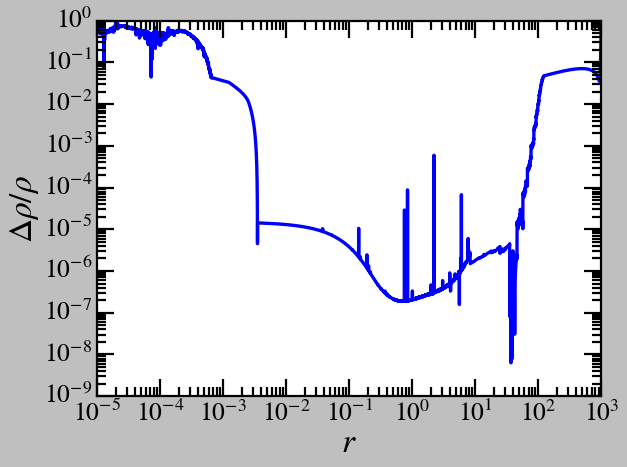

In [231]:
plt.plot(DM_profile.r_bins, np.abs(1 - DM_reconstructed_rho_bins / DM_profile.rho_bins))

plt.xlabel(r"$r$")
plt.ylabel(r"$\Delta \rho / \rho$")

plt.xscale("log")
plt.yscale("log")

plt.tight_layout()
plt.show()

In [232]:
star_reconstructed_rho_bins = star_profile.reconstruct_density(
    total_phi_bins=star_profile.total_phi_bins,
    eps_bins=star_profile.eps_bins,
    f_eps_bins=star_profile.f_eps_bins,
)

Reconstructing densities: 100%|██████████| 10000/10000 [00:20<00:00, 484.29it/s]


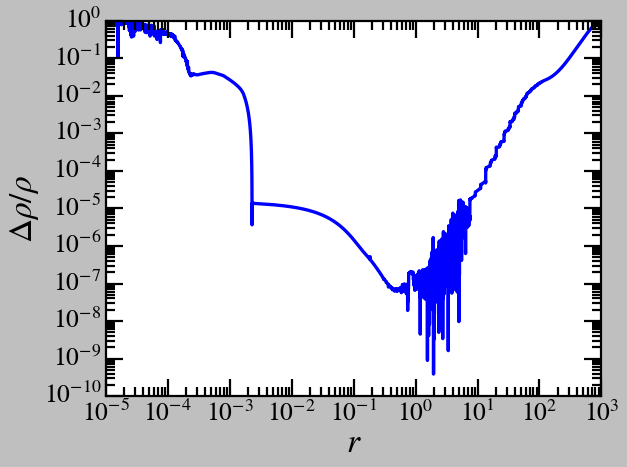

In [233]:
plt.plot(
    star_profile.r_bins, np.abs(1 - star_reconstructed_rho_bins / star_profile.rho_bins)
)

plt.xlabel(r"$r$")
plt.ylabel(r"$\Delta \rho / \rho$")

plt.xscale("log")
plt.yscale("log")

plt.tight_layout()
plt.show()

In [234]:
DM_N_part = int(1e6)

DM_sampler = sampling.SampleParticles(
    r_bins=DM_profile.r_bins,
    rho_bins=DM_profile.rho_bins,
    mass_bins=DM_profile.mass_bins,
    total_phi_bins=DM_profile.total_phi_bins,
    eps_bins=DM_profile.eps_bins,
    f_eps_bins=DM_profile.f_eps_bins,
    r_sample_min=1e-4,
    r_sample_max=5 * DM_profile.c,
    N_part=DM_N_part,
)

Sampling velocities: 100%|██████████| 9999/9999 [00:08<00:00, 1135.91it/s]


In [235]:
DM_halo = utils.Halo()
DM_halo.input_from_particles(
    part_coords=DM_sampler.part_coords,
    part_velocs=DM_sampler.part_velocs,
    part_mass=DM_sampler.part_mass,
)

sampled_L_x, sampled_L_y, sampled_L_z = DM_halo.get_angular_momenta()

(
    DM_sampled_r_bins,
    DM_sampled_rho_bins,
    DM_sampled_rho_bins_err,
    DM_sampled_sigma_r_bins,
    DM_sampled_sigma_r_bins_err,
) = DM_halo.get_profiles()

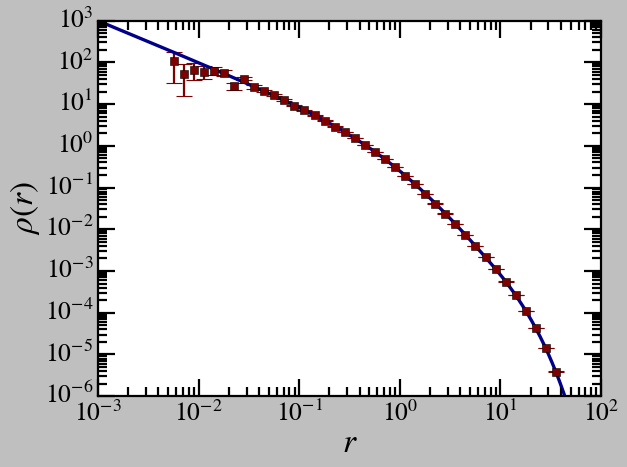

In [236]:
plt.errorbar(
    DM_sampled_r_bins,
    DM_sampled_rho_bins,
    yerr=DM_sampled_rho_bins_err,
    fmt=" s",
    color="maroon",
    markersize=7.5,
    elinewidth=2,
    capsize=7.5,
    capthick=1,
)

plt.plot(DM_profile.r_bins, DM_profile.rho_bins, color="darkblue")

plt.xlim(1e-3, 1e2)
plt.ylim(1e-6, 1e3)

plt.xscale("log")
plt.yscale("log")

plt.xlabel(r"$r$")
plt.ylabel(r"$\rho (r)$")

plt.tight_layout()
plt.show()

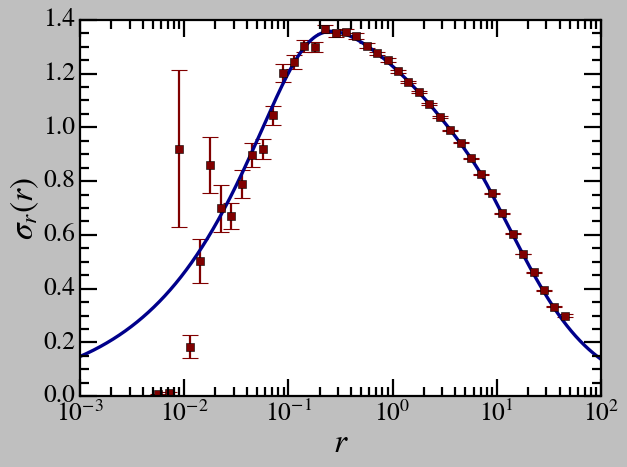

In [237]:
plt.errorbar(
    DM_sampled_r_bins,
    DM_sampled_sigma_r_bins,
    yerr=DM_sampled_sigma_r_bins_err,
    fmt=" s",
    color="maroon",
    markersize=7.5,
    elinewidth=2,
    capsize=7.5,
    capthick=1,
)

plt.plot(DM_profile.r_bins, DM_profile.sigma_r_bins, color="darkblue")

plt.xlim(1e-3, 1e2)

plt.xscale("log")
# plt.yscale("log")

plt.xlabel(r"$r$")
plt.ylabel(r"$\sigma_r (r)$")

plt.tight_layout()
plt.show()

In [238]:
star_N_part = int(1e5)

star_sampler = sampling.SampleParticles(
    r_bins=star_profile.r_bins,
    rho_bins=star_profile.rho_bins,
    mass_bins=star_profile.mass_bins,
    total_phi_bins=star_profile.total_phi_bins,
    eps_bins=star_profile.eps_bins,
    f_eps_bins=star_profile.f_eps_bins,
    r_sample_min=1e-4,
    r_sample_max=5 * DM_profile.c,
    N_part=star_N_part,
)

Sampling velocities: 100%|██████████| 9999/9999 [00:03<00:00, 2666.53it/s] 


In [239]:
star_halo = utils.Halo()
star_halo.input_from_particles(
    part_coords=star_sampler.part_coords,
    part_velocs=star_sampler.part_velocs,
    part_mass=star_sampler.part_mass,
)

sampled_L_x, sampled_L_y, sampled_L_z = star_halo.get_angular_momenta()

(
    star_sampled_r_bins,
    star_sampled_rho_bins,
    star_sampled_rho_bins_err,
    star_sampled_sigma_r_bins,
    star_sampled_sigma_r_bins_err,
) = star_halo.get_profiles()

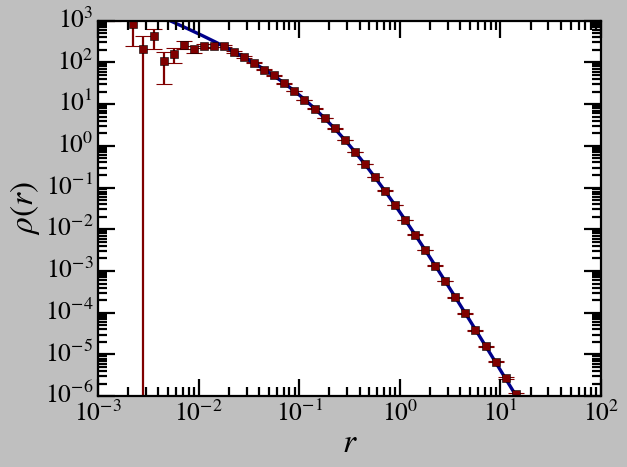

In [240]:
plt.errorbar(
    star_sampled_r_bins,
    star_sampled_rho_bins,
    yerr=star_sampled_rho_bins_err,
    fmt=" s",
    color="maroon",
    markersize=7.5,
    elinewidth=2,
    capsize=7.5,
    capthick=1,
)

plt.plot(star_profile.r_bins, star_profile.rho_bins, color="darkblue")

plt.xlim(1e-3, 1e2)
plt.ylim(1e-6, 1e3)

plt.xscale("log")
plt.yscale("log")

plt.xlabel(r"$r$")
plt.ylabel(r"$\rho (r)$")

plt.tight_layout()
plt.show()

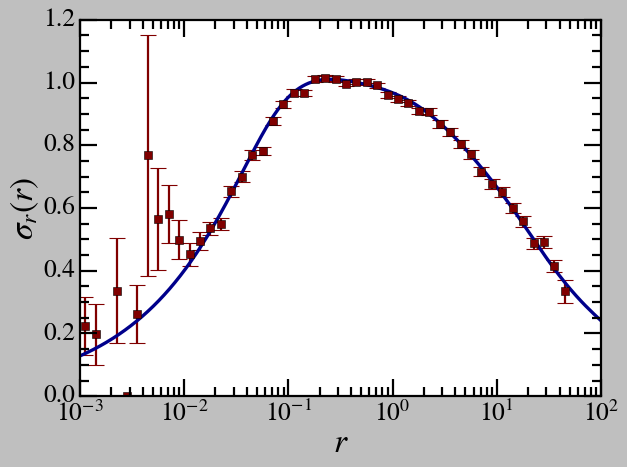

In [241]:
plt.errorbar(
    star_sampled_r_bins,
    star_sampled_sigma_r_bins,
    yerr=star_sampled_sigma_r_bins_err,
    fmt=" s",
    color="maroon",
    markersize=7.5,
    elinewidth=2,
    capsize=7.5,
    capthick=1,
)

plt.plot(star_profile.r_bins, star_profile.sigma_r_bins, color="darkblue")

plt.xlim(1e-3, 1e2)

plt.xscale("log")
# plt.yscale("log")

plt.xlabel(r"$r$")
plt.ylabel(r"$\sigma_r (r)$")

plt.tight_layout()
plt.show()

In [242]:
rs = 25.48
rhos = 3.60e06

unit_length = rs
unit_mass = rhos * rs**3 / 1e10
unit_velocity = np.sqrt(G * rhos * rs**2)
unit_energy = unit_velocity**2

In [243]:
DM_data = {
    "ParticleIDs": np.arange(1, DM_sampler._N_part + 1, dtype=np.int32),
    "Coordinates": DM_sampler.part_coords * unit_length,
    "Velocities": DM_sampler.part_velocs * unit_velocity,
    "Masses": np.full(
        DM_sampler._N_part, DM_sampler.part_mass * unit_mass, dtype=np.float64
    ),
}

star_data = {
    "ParticleIDs": DM_sampler._N_part
    + np.arange(1, star_sampler._N_part + 1, dtype=np.int32),
    "Coordinates": star_sampler.part_coords * unit_length,
    "Velocities": star_sampler.part_velocs * unit_velocity,
    "Masses": np.full(
        star_sampler._N_part, star_sampler.part_mass * unit_mass, dtype=np.float64
    ),
}

In [244]:
writer = ICsWriter(
    PartType1=DM_data,
    PartType2=star_data,
)

writer.write(filename="../../ICs/ICs_dm_star_mix_soft.hdf5")